In [5]:
from qdrant_client import QdrantClient
from dotenv import load_dotenv
import torch, os, seaborn as sns, pandas as pd, matplotlib.pyplot as plt
from utils import *
from umap import UMAP
from torch.nn.functional import normalize
from torchmetrics.functional.retrieval import (
        retrieval_hit_rate, retrieval_precision,
        retrieval_reciprocal_rank, retrieval_normalized_dcg
)

In [6]:
load_dotenv('/kaggle/input/datasets/enol00/secret/.env')

COLLECTION_NAME = "used cars dataset"

api_key = os.getenv('QDRANT_API_KEY')
api_url = os.getenv('QDRANT_URL')

client = QdrantClient(
    api_key=api_key,
    url=api_url,
)

In [7]:
records = client.scroll(
    collection_name=COLLECTION_NAME,
    limit=4000,
    with_vectors=True,
    with_payload=["brand", "model", "url"]
)[0]


vectors = np.stack([record.vector for record in records])

ids = np.array([record.payload['url'] for record in records], dtype="U64")

metadata = np.array([record.payload['brand'] + record.payload["model"] for record in records], dtype="U64")

In [8]:
df = pd.DataFrame(
    {"raw_url": ids, "vector": list(vectors), "metadata": metadata}
)

df["clean_url"] = df["raw_url"].apply(get_clean_offer_url)

offer_counts = df["clean_url"].value_counts()
exact_8_offers = offer_counts[offer_counts == 8].index
df = df[df["clean_url"].isin(exact_8_offers)].copy().reset_index(drop=True)

In [9]:
X_tensor = torch.tensor(np.vstack(df["vector"].values), dtype=torch.float32)

X_norm = normalize(X_tensor, p=2, dim=1)
sim_matrix = torch.mm(X_norm, X_norm.T)

sim_matrix.fill_diagonal_(-float("inf"))

TOP_K = 8
num_samples = len(df)

urls_array = df["clean_url"].values
meta_array = df["metadata"].values

hits_url_list = []
precisions_meta_list = []
mrrs_url_list = []
ndcgs_or_list = []

for i in range(num_samples):
    preds = sim_matrix[i]  

    target_url = urls_array[i]
    target_meta = meta_array[i]

    url_target_tensor = torch.tensor(
        urls_array == target_url, dtype=torch.bool
    )
    meta_target_tensor = torch.tensor(
        meta_array == target_meta, dtype=torch.bool
    )

    hit_val = retrieval_hit_rate(preds, url_target_tensor, top_k=TOP_K)
    hits_url_list.append(hit_val.item())

    prec_val = retrieval_precision(preds, meta_target_tensor, top_k=TOP_K)
    precisions_meta_list.append(prec_val.item())

    mrr_val = retrieval_reciprocal_rank(
        preds, url_target_tensor, top_k=TOP_K
    )
    mrrs_url_list.append(mrr_val.item())

    or_target_tensor = url_target_tensor | meta_target_tensor

    ndcg_val = retrieval_normalized_dcg(
        preds, or_target_tensor, top_k=TOP_K
    )
    ndcgs_or_list.append(ndcg_val.item())

print(f"Top K = {TOP_K}")
print(f"Hit@{TOP_K} (URL): {np.mean(hits_url_list):.4f}")
print(f"Precision@{TOP_K} (Metadata): {np.mean(precisions_meta_list):.4f}")
print(f"MRR@{TOP_K} (URL): {np.mean(mrrs_url_list):.4f}")
print(f"nDCG@{TOP_K} (URL OR Metadata): {np.mean(ndcgs_or_list):.4f}")

Top K = 8
Hit@8 (URL): 0.8062
Precision@8 (Metadata): 0.2662
MRR@8 (URL): 0.6482
nDCG@8 (URL OR Metadata): 0.3334


In [10]:
reducer = UMAP(
    n_neighbors=15,
    min_dist=0.5,
    metric='cosine',
    random_state=42
)

embedding_2d = reducer.fit_transform(np.vstack(df["vector"].values))

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [11]:
df = pd.DataFrame({
    'UMAP 1': embedding_2d[:, 0],
    'UMAP 2': embedding_2d[:, 1],
    'url': urls_array
})


def get_spread(group):
    val = calculate_spread(group[["UMAP 1", "UMAP 2"]])
    return val.mean() if hasattr(val, "mean") else float(val)


url_spreads = df.groupby("url").apply(get_spread)

selected_offers = url_spreads.nlargest(10).index.tolist()


def name_from_clean_url(clean_url: str) -> str:
    return f"offer: {clean_url.rstrip('/').split('/')[-1]}"


offer_to_label = {
    offer: name_from_clean_url(offer) for offer in selected_offers
}

df["display_group"] = df["url"].map(lambda x: offer_to_label.get(x, "others"))

df_background = df[df["display_group"] == "others"]
df_highlighted = df[df["display_group"] != "others"]

print(f'number of unique records: {len(df)}')

number of unique records: 872


/tmp/ipykernel_58/881268995.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  url_spreads = df.groupby("url").apply(get_spread)


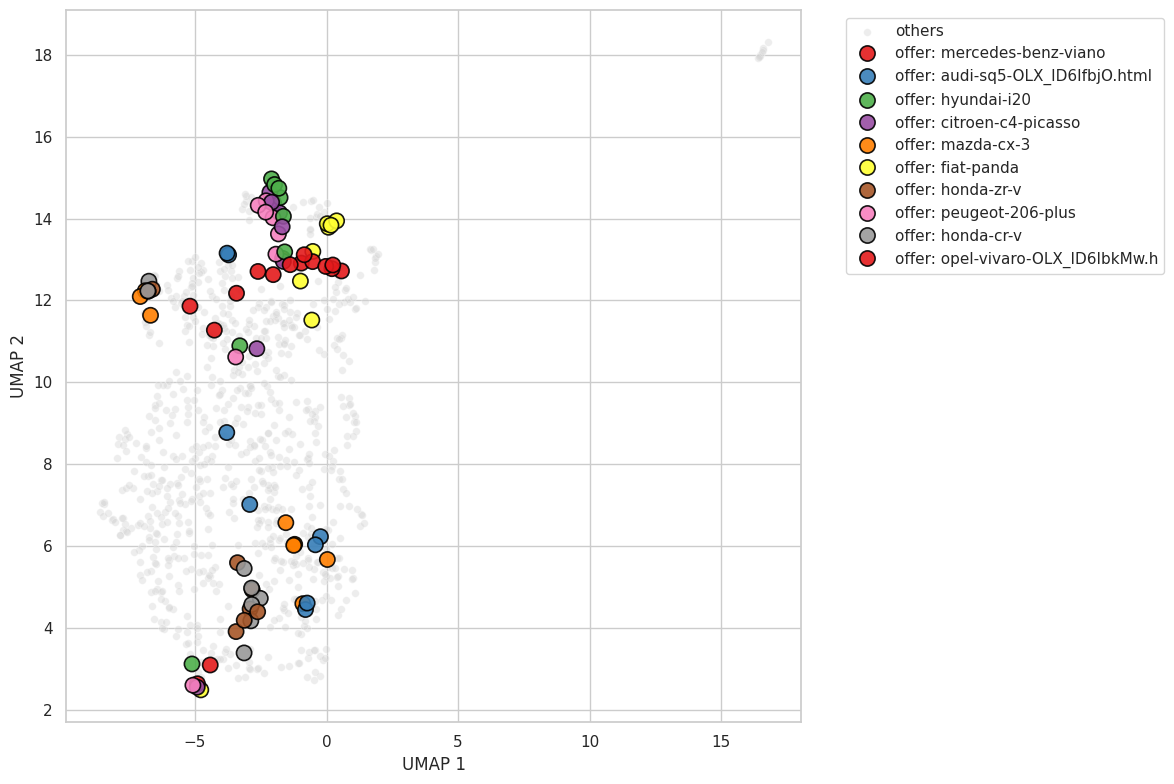

In [12]:
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

sns.scatterplot(
    data=df_background, x='UMAP 1', y='UMAP 2',
    color='#d3d3d3', alpha=0.4, s=30, label="others"
)

sns.scatterplot(
    data=df_highlighted, x='UMAP 1', y='UMAP 2',
    hue='display_group', palette='Set1', s=120, alpha=0.9,
    edgecolor='black', linewidth=1.2
)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()